In [4]:
# ============================================================
# PHASE 12
# AI Recommendation Engine
# ============================================================

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [6]:
master = pd.read_csv(

    "../data/final/master_dataset_predicted.csv"

)

master.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,Start_Year,Year_yield,Area_yield,Production_yield,fertilizer,pesticide,Yield_yield,Year_weather,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,End_Year,Decade,Year_Group,Rainfall_Category,Temperature_Category,Humidity_Category,Production_per_Hectare,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rainfall_per_Hectare,Crop_Category,Production_Level,Yield_Level,Weather_Data_Available,Soil_Data_Available,Predicted_Yield,Prediction_Error,Absolute_Error,Yield_Prediction_Category
0,Andaman And Nicobar Islands,Nicobars,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.643541,NaN,NaN,NaN,Other,Medium,Medium,False,False,NaN,NaN,NaN,NaN
1,Andaman And Nicobar Islands,Nicobars,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.655803,NaN,NaN,NaN,Other,Medium,Medium,False,False,NaN,NaN,NaN,NaN
2,Andaman And Nicobar Islands,Nicobars,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004,2000,2001-2005,NaN,NaN,NaN,1.209358,NaN,NaN,NaN,Other,Medium,Medium,False,False,NaN,NaN,NaN,NaN
3,Andaman And Nicobar Islands,North And Middle Andaman,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.690000,NaN,NaN,NaN,Other,High,Medium,False,False,NaN,NaN,NaN,NaN
4,Andaman And Nicobar Islands,South Andamans,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.696296,NaN,NaN,NaN,Other,High,Medium,False,False,NaN,NaN,NaN,NaN


In [7]:
print("="*70)

print("MASTER DATASET")

print("="*70)

print()

print("Shape :",master.shape)

print()

master.info()

MASTER DATASET

Shape : (345374, 44)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345374 entries, 0 to 345373
Data columns (total 44 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      345374 non-null  object 
 1   District                   345374 non-null  object 
 2   Crop                       345374 non-null  object 
 3   Year                       345374 non-null  object 
 4   Season                     345374 non-null  object 
 5   Area                       345374 non-null  float64
 6   Area Units                 345374 non-null  object 
 7   Production                 340414 non-null  float64
 8   Production Units           345374 non-null  object 
 9   Yield                      345374 non-null  float64
 10  Start_Year                 345374 non-null  int64  
 11  Year_yield                 318023 non-null  float64
 12  Area_yield                 318023 non-null  floa

In [8]:
def generate_recommendation(row):

    recommendations = []

    management = []


    # ======================================================
    # WEATHER
    # ======================================================

    if pd.notna(row["total_rainfall_mm"]):

        if row["total_rainfall_mm"] < 900:

            recommendations.append(
                "Increase Irrigation"
            )

            management.append(
                "Water Management"
            )

        elif row["total_rainfall_mm"] > 1800:

            recommendations.append(
                "Improve Drainage"
            )

            management.append(
                "Water Management"
            )

    if pd.notna(row["avg_temp_c"]):

        if row["avg_temp_c"] > 28:

            recommendations.append(
                "Use Heat Resistant Variety"
            )

            management.append(
                "Climate Adaptation"
            )


    if pd.notna(row["avg_humidity_percent"]):

        if row["avg_humidity_percent"] > 75:

            recommendations.append(
                "Monitor Fungal Diseases"
            )

            management.append(
                "Crop Protection"
            )


    # ======================================================
    # SOIL
    # ======================================================

    if pd.notna(row["N"]):

        if row["N"] < 40:

            recommendations.append(
                "Apply Nitrogen Fertilizer"
            )

            management.append(
                "Nutrient Management"
            )


    if pd.notna(row["P"]):

        if row["P"] < 30:

            recommendations.append(
                "Increase Phosphorus"
            )

            management.append(
                "Nutrient Management"
            )


    if pd.notna(row["K"]):

        if row["K"] < 30:

            recommendations.append(
                "Apply Potassium Fertilizer"
            )

            management.append(
                "Nutrient Management"
            )


    if pd.notna(row["pH"]):

        if row["pH"] < 6:

            recommendations.append(
                "Apply Lime"
            )

            management.append(
                "Soil Management"
            )

        elif row["pH"] > 7.5:

            recommendations.append(
                "Add Organic Matter"
            )

            management.append(
                "Soil Management"
            )


    # ======================================================
    # MISSING DATA
    # ======================================================

    if (

        pd.isna(row["avg_temp_c"])

        or

        pd.isna(row["total_rainfall_mm"])

        or

        pd.isna(row["N"])

        or

        pd.isna(row["P"])

        or

        pd.isna(row["K"])

        or

        pd.isna(row["pH"])

    ):

        recommendations.append(

            "Collect Missing Weather / Soil Data"

        )

        management.append(

            "Data Collection"

        )


    # ======================================================
    # ML BASED PRIORITY
    # ======================================================

    prediction = row["Predicted_Yield"]


    if prediction < 0.75:

        priority = "Immediate Action Required"

        recommendations.append(

            "Expected Yield is Extremely Low"

        )

        management.append(

            "Yield Improvement"

        )


    elif prediction < 2:

        priority = "High Priority"

        recommendations.append(

            "Expected Yield is Low"

        )

        management.append(

            "Yield Improvement"

        )


    elif prediction < 4:

        priority = "Moderate Priority"

        recommendations.append(

            "Optimize Farming Practices"

        )

        management.append(

            "Yield Optimization"

        )


    else:

        priority = "Routine Monitoring"

        recommendations.append(

            "Maintain Current Practices"

        )

        management.append(

            "Farm Management"

        )


    recommendations = sorted(set(recommendations))

    management = sorted(set(management))


    return pd.Series(

        [

            " | ".join(recommendations),

            ", ".join(management),

            priority

        ]

    )

In [9]:
master[
    [
        "Recommendation",
        "Management_Area",
        "Priority"
    ]
] = master.apply(
    generate_recommendation,
    axis=1
)

In [10]:
master[

    [

        "State",

        "Crop",

        "Yield",

        "Predicted_Yield",

        "Recommendation",

        "Management_Area",

        "Priority"

    ]

].head(200)

,State,Crop,Yield,Predicted_Yield,Recommendation,Management_Area,Priority
0,Andaman And Nicobar Islands,Arecanut,1.643541,NaN,Collect Missing Weather / Soil Data | Maintain...,"Data Collection, Farm Management",Routine Monitoring
1,Andaman And Nicobar Islands,Arecanut,1.655803,NaN,Collect Missing Weather / Soil Data | Maintain...,"Data Collection, Farm Management",Routine Monitoring
2,Andaman And Nicobar Islands,Arecanut,1.209358,NaN,Collect Missing Weather / Soil Data | Maintain...,"Data Collection, Farm Management",Routine Monitoring
3,Andaman And Nicobar Islands,Arecanut,1.690000,NaN,Collect Missing Weather / Soil Data | Maintain...,"Data Collection, Farm Management",Routine Monitoring
4,Andaman And Nicobar Islands,Arecanut,1.696296,NaN,Collect Missing Weather / Soil Data | Maintain...,"Data Collection, Farm Management",Routine Monitoring
...,...,...,...,...,...,...,...
195,Andhra Pradesh,Bajra,0.878763,1.051993,Apply Potassium Fertilizer | Expected Yield is...,"Climate Adaptation, Nutrient Management, Water...",High Priority
196,Andhra Pradesh,Bajra,0.852854,1.128587,Apply Potassium Fertilizer | Expected Yield is...,"Climate Adaptation, Nutrient Management, Water...",High Priority
197,Andhra Pradesh,Bajra,0.987013,0.962648,Apply Potassium Fertilizer | Expected Yield is...,"Climate Adaptation, Nutrient Management, Yield...",High Priority
198,Andhra Pradesh,Bajra,1.000000,0.723777,Apply Potassium Fertilizer | Expected Yield is...,"Climate Adaptation, Nutrient Management, Yield...",Immediate Action Required


In [11]:
master[
    [
        "State",
        "Crop",
        "Yield",
        "Predicted_Yield",
        "Recommendation",
        "Management_Area",
        "Priority"
    ]
].tail(20)

,State,Crop,Yield,Predicted_Yield,Recommendation,Management_Area,Priority
345354,West Bengal,Wheat,1.827943,1.962086,Expected Yield is Low,Yield Improvement,High Priority
345355,West Bengal,Wheat,1.887480,1.862707,Expected Yield is Low | Monitor Fungal Diseases,"Crop Protection, Yield Improvement",High Priority
345356,West Bengal,Wheat,1.845659,2.381288,Optimize Farming Practices,Yield Optimization,Moderate Priority
345357,West Bengal,Wheat,2.279052,2.357607,Optimize Farming Practices,Yield Optimization,Moderate Priority
345358,West Bengal,Wheat,2.296071,2.363467,Optimize Farming Practices,Yield Optimization,Moderate Priority
345359,West Bengal,Wheat,2.284198,2.247568,Monitor Fungal Diseases | Optimize Farming Pra...,"Crop Protection, Yield Optimization",Moderate Priority
345360,West Bengal,Wheat,2.358749,2.360397,Optimize Farming Practices,Yield Optimization,Moderate Priority
345361,West Bengal,Wheat,2.756040,2.309921,Optimize Farming Practices,Yield Optimization,Moderate Priority
345362,West Bengal,Wheat,2.256210,2.333446,Optimize Farming Practices,Yield Optimization,Moderate Priority
345363,West Bengal,Wheat,2.157555,2.229755,Monitor Fungal Diseases | Optimize Farming Pra...,"Crop Protection, Yield Optimization",Moderate Priority


In [12]:
priority_summary = (

    master["Priority"]

    .value_counts()

    .reset_index()

)

priority_summary.columns = [

    "Priority",

    "Count"

]

priority_summary

,Priority,Count
0,High Priority,115271
1,Immediate Action Required,111353
2,Routine Monitoring,79833
3,Moderate Priority,38917


In [13]:
management_summary = (

    master["Management_Area"]

    .value_counts()

    .reset_index()

)

management_summary.columns = [

    "Management Area",

    "Count"

]

management_summary

,Management Area,Count
0,"Nutrient Management, Yield Improvement",76035
1,"Nutrient Management, Water Management, Yield I...",47904
2,"Soil Management, Yield Improvement",23000
3,"Data Collection, Farm Management",21587
4,"Crop Protection, Nutrient Management, Soil Man...",15366
...,...,...
56,"Crop Protection, Farm Management, Nutrient Man...",65
57,"Crop Protection, Nutrient Management, Yield Op...",21
58,"Crop Protection, Nutrient Management, Water Ma...",7
59,"Crop Protection, Nutrient Management, Water Ma...",6


In [14]:
recommendation_summary = (

    master["Recommendation"]

    .value_counts()

    .head(10)

    .reset_index()

)

recommendation_summary.columns = [

    "Recommendation",

    "Count"

]

recommendation_summary

,Recommendation,Count
0,Apply Potassium Fertilizer | Expected Yield is...,27820
1,Apply Potassium Fertilizer | Expected Yield is...,25716
2,Collect Missing Weather / Soil Data | Maintain...,21587
3,Add Organic Matter | Expected Yield is Low,13860
4,Apply Potassium Fertilizer | Expected Yield is...,12708
5,Apply Potassium Fertilizer | Expected Yield is...,12305
6,Expected Yield is Extremely Low | Increase Pho...,11783
7,Apply Potassium Fertilizer | Maintain Current ...,11194
8,Expected Yield is Low | Increase Phosphorus,10716
9,Apply Potassium Fertilizer | Expected Yield is...,9629


In [15]:
sample = master[
    [
        "State",
        "Crop",
        "Yield",
        "Predicted_Yield",
        "Prediction_Error",
        "Priority"
    ]
].sample(

    15,

    random_state=42

)

sample

,State,Crop,Yield,Predicted_Yield,Prediction_Error,Priority
177778,Andhra Pradesh,Ragi,1.428571,1.522879,-0.094307,High Priority
58135,Karnataka,Gram,0.135987,0.142890,-0.006903,Immediate Action Required
217284,Uttar Pradesh,Groundnut,0.741016,0.756553,-0.015537,High Priority
316252,Karnataka,Rice,2.919196,2.889922,0.029274,Moderate Priority
93143,Bihar,Sweet Potato,13.153846,13.267057,-0.113211,Routine Monitoring
117304,Rajasthan,Masoor,0.750000,NaN,NaN,Routine Monitoring
135293,Assam,Tapioca,7.250000,7.982969,-0.732969,Routine Monitoring
249629,Madhya Pradesh,Onion,20.355688,21.669210,-1.313523,Routine Monitoring
9853,Chhattisgarh,Other Kharif Pulses,0.275862,0.270295,0.005567,Immediate Action Required
88587,Assam,Maize,0.602888,0.627324,-0.024436,Immediate Action Required


In [16]:
print("="*70)

print("RECOMMENDATION SUMMARY")

print("="*70)

print()

print("Total Records :",len(master))

print()

print("Priority Distribution")

print(priority_summary)

print()

print("Management Areas")

print(management_summary)

RECOMMENDATION SUMMARY

Total Records : 345374

Priority Distribution
                    Priority   Count
0              High Priority  115271
1  Immediate Action Required  111353
2         Routine Monitoring   79833
3          Moderate Priority   38917

Management Areas
                                      Management Area  Count
0              Nutrient Management, Yield Improvement  76035
1   Nutrient Management, Water Management, Yield I...  47904
2                  Soil Management, Yield Improvement  23000
3                    Data Collection, Farm Management  21587
4   Crop Protection, Nutrient Management, Soil Man...  15366
..                                                ...    ...
56  Crop Protection, Farm Management, Nutrient Man...     65
57  Crop Protection, Nutrient Management, Yield Op...     21
58  Crop Protection, Nutrient Management, Water Ma...      7
59  Crop Protection, Nutrient Management, Water Ma...      6
60  Crop Protection, Farm Management, Nutrient Man...   

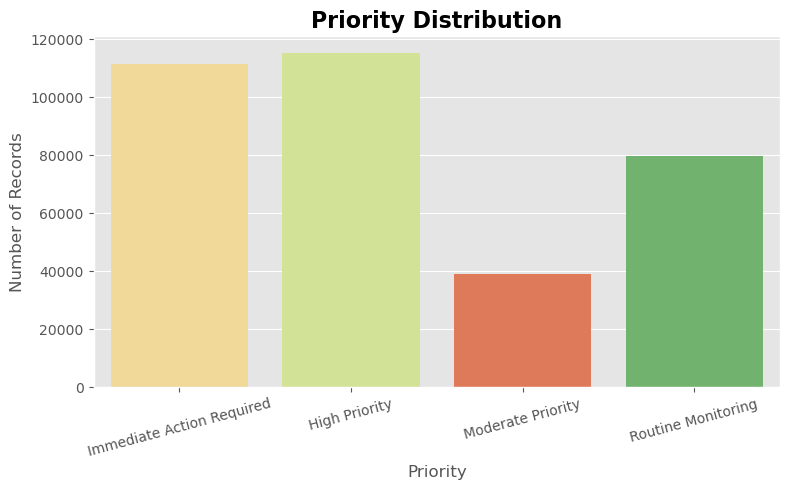

In [17]:
plt.figure(figsize=(8,5))

order = [

    "Immediate Action Required",

    "High Priority",

    "Moderate Priority",

    "Routine Monitoring"

]

sns.countplot(

    data=master,

    x="Priority",

    order=order,

    hue="Priority",

    palette="RdYlGn_r",

    legend=False

)

plt.title(

    "Priority Distribution",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Priority")

plt.ylabel("Number of Records")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

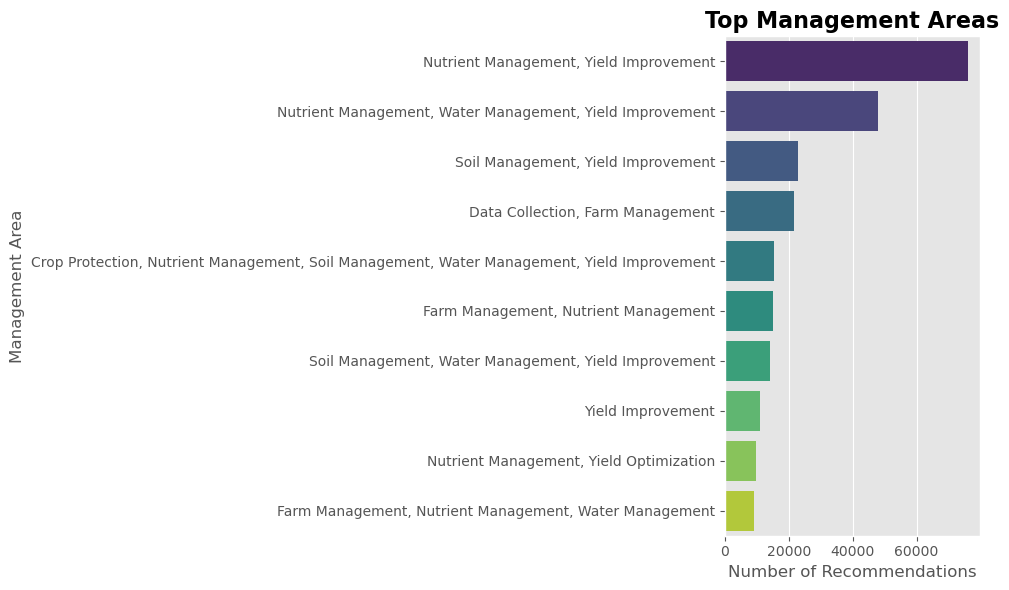

In [18]:
management = (

    master["Management_Area"]

    .value_counts()

    .head(10)

)

plt.figure(figsize=(10,6))

sns.barplot(

    x=management.values,

    y=management.index,

    hue=management.index,

    palette="viridis",

    legend=False

)

plt.title(

    "Top Management Areas",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Number of Recommendations")

plt.ylabel("Management Area")

plt.tight_layout()

plt.show()

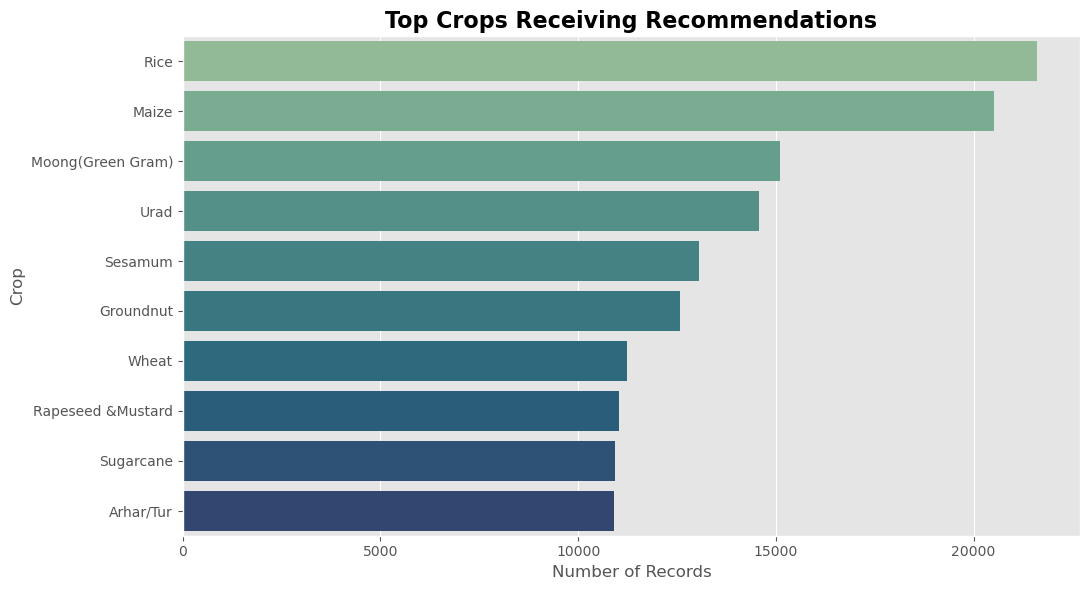

In [19]:
crop_rec = (

    master

    .groupby("Crop")["Priority"]

    .count()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(11,6))

sns.barplot(

    x=crop_rec.values,

    y=crop_rec.index,

    hue=crop_rec.index,

    palette="crest",

    legend=False

)

plt.title(

    "Top Crops Receiving Recommendations",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Number of Records")

plt.ylabel("Crop")

plt.tight_layout()

plt.show()

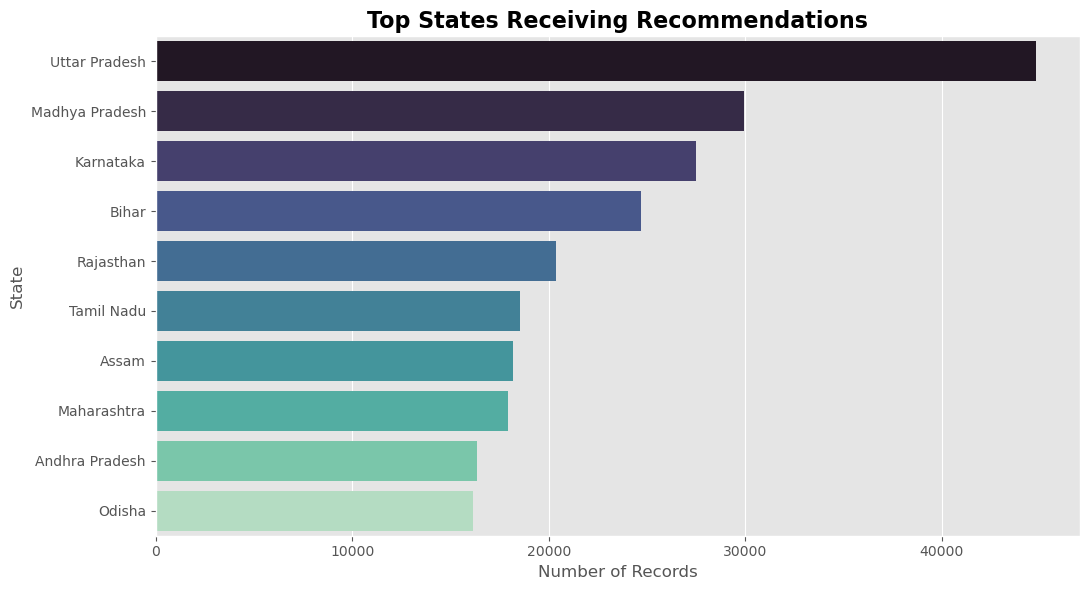

In [20]:
state_rec = (

    master

    .groupby("State")["Priority"]

    .count()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(11,6))

sns.barplot(

    x=state_rec.values,

    y=state_rec.index,

    hue=state_rec.index,

    palette="mako",

    legend=False

)

plt.title(

    "Top States Receiving Recommendations",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Number of Records")

plt.ylabel("State")

plt.tight_layout()

plt.show()

In [22]:
print("="*80)

print("BUSINESS INSIGHTS")

print("="*80)

print()

print("1. Priority is assigned using Machine Learning predicted yield.")

print()

print("2. Weather and soil parameters generate management recommendations.")

print()

print("3. Low predicted yield indicates farms requiring immediate intervention.")

print()

print("4. High predicted yield suggests existing practices are effective.")

print()

print("5. Missing weather or soil information highlights areas where additional data collection is required.")

print()

print("6. This hybrid recommendation engine combines Machine Learning predictions with agricultural domain rules.")

BUSINESS INSIGHTS

1. Priority is assigned using Machine Learning predicted yield.

2. Weather and soil parameters generate management recommendations.

3. Low predicted yield indicates farms requiring immediate intervention.

4. High predicted yield suggests existing practices are effective.

5. Missing weather or soil information highlights areas where additional data collection is required.

6. This hybrid recommendation engine combines Machine Learning predictions with agricultural domain rules.


In [23]:
master.to_csv(

    "../data/final/master_dataset_recommendation.csv",

    index=False

)

print("Recommendation Dataset Saved Successfully.")

Recommendation Dataset Saved Successfully.


In [24]:
print("="*80)

print("PHASE 12 VERIFICATION")

print("="*80)

verification = pd.DataFrame({

    "Module":[

        "Recommendation Engine",

        "Management Area",

        "Priority Assignment",

        "Visualizations",

        "Business Insights",

        "Dataset Export"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "PASS"

    ]

})

display(verification)

PHASE 12 VERIFICATION


,Module,Status
0,Recommendation Engine,Completed
1,Management Area,Completed
2,Priority Assignment,Completed
3,Visualizations,Completed
4,Business Insights,Completed
5,Dataset Export,PASS
